<a href="https://colab.research.google.com/github/harshpailkar/vggly/blob/main/vggly_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [53]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from torchvision.models import vgg19, VGG19_Weights
from PIL import Image

In [54]:
std = torch.tensor((0.229, 0.224, 0.225)).view(3, 1, 1)
mean = torch.tensor((0.485, 0.456, 0.406)).view(3, 1, 1)

def load_image(path, max_size = 128, shape = None):

  image = Image.open(path).convert('RGB')

  size = max_size if max(image.size) > max_size else max(image.size)
  if shape is not None:
    size = shape

  transform = transforms.Compose([
      transforms.Resize(size),
      transforms.ToTensor(),
      transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
  ])

  image = transform(image).unsqueeze(0)

  return image

def show_image(image_tensor):
  image = image_tensor.clone().detach().cpu().squeeze(0)
  image = image * std + mean
  image = torch.clamp(image, min=0, max=1)

  return transforms.ToPILImage()(image)

In [55]:
model = models.vgg19(weights=VGG19_Weights.IMAGENET1K_V1).features

for p in model.parameters():
  p.requires_grad_(False)

In [56]:
layers = {
    '0':  'conv1_1',
    '5':  'conv2_1',
    '10': 'conv3_1',
    '19': 'conv4_1',
    '21': 'conv4_2', # content layer
    '28': 'conv5_1'
}

def get_features(image, model, layers):
  features = {}
  x = image

  for idx, layer in model._modules.items():
    x = layer(x)

    if (idx in layers):
      features[layers[idx]] = x

  return features

In [57]:
def gram_matrix(tensor):
  _, d, h, w = tensor.shape
  tensor = tensor.view(d, h * w)
  gram = torch.mm(tensor, tensor.T)

  return gram / (d * h * w)

In [51]:
lr = 0.003
content_weight = 1
style_weight = 1e6

style_weights = {
    'conv1_1': 1.0,
    'conv2_1': 0.8,
    'conv3_1': 0.5,
    'conv4_1': 0.3,
    'conv5_1': 0.1
}

# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Load Images and move to device
content = load_image("content.png").to(device)
style = load_image("style.png", shape=content.shape[-2:]).to(device)
target = content.clone().requires_grad_(True).to(device)

# Pre-calculate features for static images
content_features = get_features(content, model, layers)
style_features = get_features(style, model, layers)

# Pre-calculate style grams ONLY for layers we need
style_grams = {layer: gram_matrix(style_features[layer]) for layer in style_weights}

optimizer = torch.optim.Adam([target], lr=lr)

for i in range(1, 301):
    target_features = get_features(target, model, layers)

    # content Loss
    content_loss = torch.mean((target_features['conv4_2'] - content_features['conv4_2'])**2)

    # style Loss
    style_loss = 0
    for layer in style_weights:
        target_feature = target_features[layer]
        target_gram = gram_matrix(target_feature)
        style_gram = style_grams[layer]

        layer_style_loss = style_weights[layer] * torch.mean((target_gram - style_gram) ** 2)
        style_loss += layer_style_loss

    # total Loss
    total_loss = (content_weight * content_loss) + (style_weight * style_loss)

    optimizer.zero_grad()
    total_loss.backward()
    optimizer.step()

    if i % 10 == 0:
        print(f"Iteration {i} | Total Loss: {total_loss.item():.4f}")

        # save or show image progress
        # final_img = show_image(target)
        # final_img.save(f"output_{i}.jpg")

Iteration 10 | Total Loss: 211.3956
Iteration 20 | Total Loss: 178.8202
Iteration 30 | Total Loss: 149.3513
Iteration 40 | Total Loss: 127.0256
Iteration 50 | Total Loss: 112.3911
Iteration 60 | Total Loss: 101.9733
Iteration 70 | Total Loss: 93.9891
Iteration 80 | Total Loss: 87.6460
Iteration 90 | Total Loss: 82.4226
Iteration 100 | Total Loss: 77.9975
Iteration 110 | Total Loss: 74.1875
Iteration 120 | Total Loss: 70.8352
Iteration 130 | Total Loss: 67.8749
Iteration 140 | Total Loss: 65.2343
Iteration 150 | Total Loss: 62.8891
Iteration 160 | Total Loss: 60.8018
Iteration 170 | Total Loss: 58.9268
Iteration 180 | Total Loss: 57.2172
Iteration 190 | Total Loss: 55.6384
Iteration 200 | Total Loss: 54.1824
Iteration 210 | Total Loss: 52.8421
Iteration 220 | Total Loss: 51.5965
Iteration 230 | Total Loss: 50.4311
Iteration 240 | Total Loss: 49.3417
Iteration 250 | Total Loss: 48.3237
Iteration 260 | Total Loss: 47.3673
Iteration 270 | Total Loss: 46.4644
Iteration 280 | Total Loss: 45.

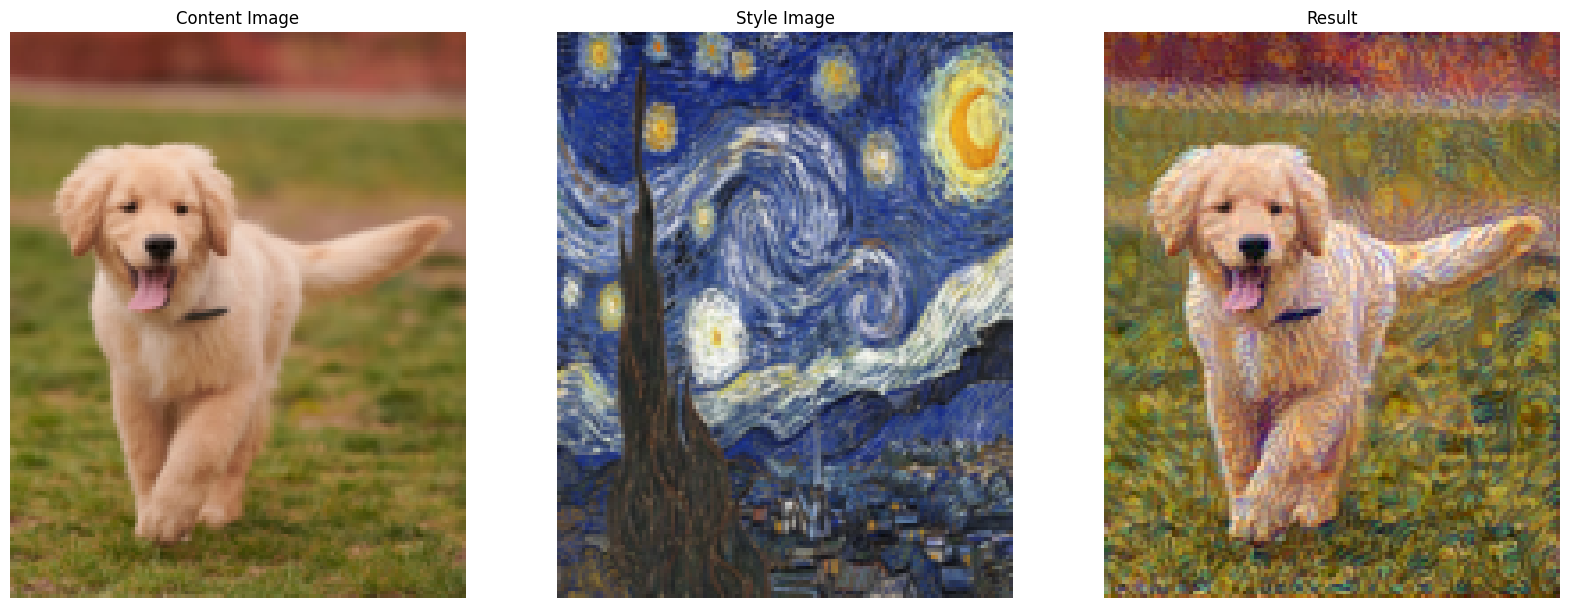

In [52]:
def create_comparison(content_tensor, style_tensor, target_tensor):
    c_img = show_image(content_tensor)
    s_img = show_image(style_tensor)
    t_img = show_image(target_tensor)

    fig, axes = plt.subplots(1, 3, figsize=(20, 10))
    axes[0].imshow(c_img); axes[0].set_title("Content Image"); axes[0].axis('off')
    axes[1].imshow(s_img); axes[1].set_title("Style Image"); axes[1].axis('off')
    axes[2].imshow(t_img); axes[2].set_title("Result"); axes[2].axis('off')

    plt.savefig("vggly_result.png", bbox_inches='tight')
    plt.show()

create_comparison(content, style, target)